# Task 2: Exploratory Data Analysis (EDA)
### Global Retail Superstore — Sales & Profitability Analysis

**Objective:** Load the dataset, examine its features with descriptive statistics,
identify trends/distributions/relationships between variables, detect outliers and
unusual patterns, and use summary statistics to answer key business questions.

**Dataset:** `retail_sales_data.csv` — 3 years (2022–2024) of retail order-level
transactions including sales, profit, discount, category, region, segment and
shipping details.

## Table of Contents
1. [Setup & Imports](#1)
2. [Load the Dataset](#2)
3. [Data Overview & Descriptive Statistics](#3)
4. [Data Cleaning](#4)
5. [Univariate Analysis — Distributions](#5)
6. [Outlier Detection](#6)
7. [Trends Over Time](#7)
8. [Relationships Between Variables](#8)
9. [Category / Region / Segment Performance](#9)
10. [Answering Key Business Questions](#10)
11. [Key Findings & Recommendations](#11)

<a id="1"></a>
## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
pd.set_option("display.max_columns", 50)

print("Libraries loaded:")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")
print(f"  seaborn {sns.__version__}")

Libraries loaded:
  pandas  3.0.2
  numpy   2.4.4
  seaborn 0.13.2


<a id="2"></a>
## 2. Load the Dataset

In [2]:
df = pd.read_csv("retail_sales_data.csv", parse_dates=["Order_Date", "Ship_Date"])
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head()

Rows: 4,515   Columns: 16


,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Region,State,City,Category,Sub_Category,Sales,Quantity,Discount,Profit
0,ORD-2025724,2024-08-26,2024-08-26,Same Day,CU-10275,Kevin Johnson,Consumer,West,Arizona,Phoenix,Furniture,Bookcases,381.58,1,0.4,-210.33
1,ORD-2026283,2022-07-24,2022-07-29,Standard Class,CU-10837,Ashley Anderson,Consumer,West,California,Los Angeles,Office Supplies,Paper,14.47,1,0.2,1.86
2,ORD-2026329,2024-11-22,2024-11-23,First Class,CU-10233,Nancy Jones,Home Office,East,New York,Buffalo,Office Supplies,Supplies,15.75,2,0.0,4.64
3,ORD-2022834,2024-04-13,2024-04-18,Standard Class,CU-10018,Nancy Taylor,Consumer,East,Massachusetts,Boston,Technology,Copiers,13213.60,3,0.2,183.61
4,ORD-2022222,2023-12-30,2024-01-02,Second Class,CU-10803,Susan Miller,Corporate,West,California,San Francisco,Office Supplies,Binders,66.58,5,0.0,19.05


In [3]:
df.columns.tolist()

['Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Region', 'State', 'City', 'Category', 'Sub_Category', 'Sales', 'Quantity', 'Discount', 'Profit']

<a id="3"></a>
## 3. Data Overview & Descriptive Statistics

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4515 entries, 0 to 4514
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       4515 non-null   str           
 1   Order_Date     4515 non-null   datetime64[us]
 2   Ship_Date      4515 non-null   datetime64[us]
 3   Ship_Mode      4402 non-null   str           
 4   Customer_ID    4515 non-null   str           
 5   Customer_Name  4515 non-null   str           
 6   Segment        4515 non-null   str           
 7   Region         4515 non-null   str           
 8   State          4515 non-null   str           
 9   City           4515 non-null   str           
 10  Category       4515 non-null   str           
 11  Sub_Category   4515 non-null   str           
 12  Sales          4515 non-null   float64       
 13  Quantity       4515 non-null   int64         
 14  Discount       4380 non-null   float64       
 15  Profit         4515 non-null   f

**Numeric feature summary:**

In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Order_Date,4515,2023-08-14 05:55:36.877076,2022-01-02 00:00:00,2022-11-17 00:00:00,2023-09-07 00:00:00,2024-05-21 12:00:00,2024-12-31 00:00:00,NaN
Ship_Date,4515,2023-08-18 00:40:49.435216,2022-01-06 00:00:00,2022-11-21 00:00:00,2023-09-10 00:00:00,2024-05-26 00:00:00,2025-01-07 00:00:00,NaN
Sales,4515.0,1392.014605,1.02,40.08,195.15,1008.09,90102.17,3942.016542
Quantity,4515.0,3.120266,1.0,1.0,3.0,4.0,37.0,2.316442
Discount,4380.0,0.109863,0.0,0.0,0.1,0.2,0.5,0.111349
Profit,4515.0,86.922837,-6392.88,0.805,9.96,60.48,15155.04,669.945493


**Categorical feature summary:**

In [6]:
df.describe(include="object").T

,count,unique,top,freq
Order_ID,4515,4500,ORD-2024969,2
Ship_Mode,4402,4,Standard Class,2612
Customer_ID,4515,849,CU-10621,13
Customer_Name,4515,350,Amy Jackson,46
Segment,4515,3,Consumer,2301
Region,4515,4,West,1374
State,4515,14,California,691
City,4515,16,Los Angeles,356
Category,4515,3,Office Supplies,2417
Sub_Category,4515,15,Art,362


**Missing values per column:**

In [7]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
Discount,135,2.99
Ship_Mode,113,2.50


**Duplicate rows:**

In [8]:
n_dupes = df.duplicated().sum()
print(f"Exact duplicate rows found: {n_dupes}")

Exact duplicate rows found: 15


<a id="4"></a>
## 4. Data Cleaning

Before analysis we handle three issues surfaced above:
- **Duplicate rows** — dropped, since they would double-count real transactions.
- **Missing `Discount`** — a missing value here reflects an order with no discount
  applied/recorded, so it is filled with `0`.
- **Missing `Ship_Mode`** — filled with the overall mode (most common shipping option),
  a reasonable default for a small number of missing categorical entries.

We also engineer a few helper columns used throughout the analysis: `Profit_Margin`
(profit as a % of sales), and `Order_Year` / `Order_Month` / `Order_YearMonth` for
time-based grouping.

In [9]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {before - len(df)} duplicate rows -> {len(df):,} rows remain")

df["Discount"] = df["Discount"].fillna(0)
df["Ship_Mode"] = df["Ship_Mode"].fillna(df["Ship_Mode"].mode()[0])

df["Profit_Margin"] = df["Profit"] / df["Sales"]
df["Order_Year"] = df["Order_Date"].dt.year
df["Order_Month"] = df["Order_Date"].dt.month
df["Order_YearMonth"] = df["Order_Date"].dt.to_period("M").astype(str)

assert df.isna().sum().sum() == 0, "Missing values remain!"
print("Missing values remaining:", df.isna().sum().sum())
df[["Sales", "Quantity", "Discount", "Profit", "Profit_Margin"]].describe().T

Dropped 15 duplicate rows -> 4,500 rows remain
Missing values remaining: 0


,count,mean,std,min,25%,50%,75%,max
Sales,4500.0,1391.264189,3947.289451,1.020000,39.977500,194.705000,1003.887500,90102.170000
Quantity,4500.0,3.121333,2.319249,1.000000,1.000000,3.000000,4.000000,37.000000
Discount,4500.0,0.106733,0.111319,0.000000,0.000000,0.100000,0.150000,0.500000
Profit,4500.0,86.269136,670.569113,-6392.880000,0.785000,9.940000,59.992500,15155.040000
Profit_Margin,4500.0,0.112093,0.226825,-0.927415,0.022395,0.169957,0.268401,0.488095


<a id="5"></a>
## 5. Univariate Analysis — Distributions

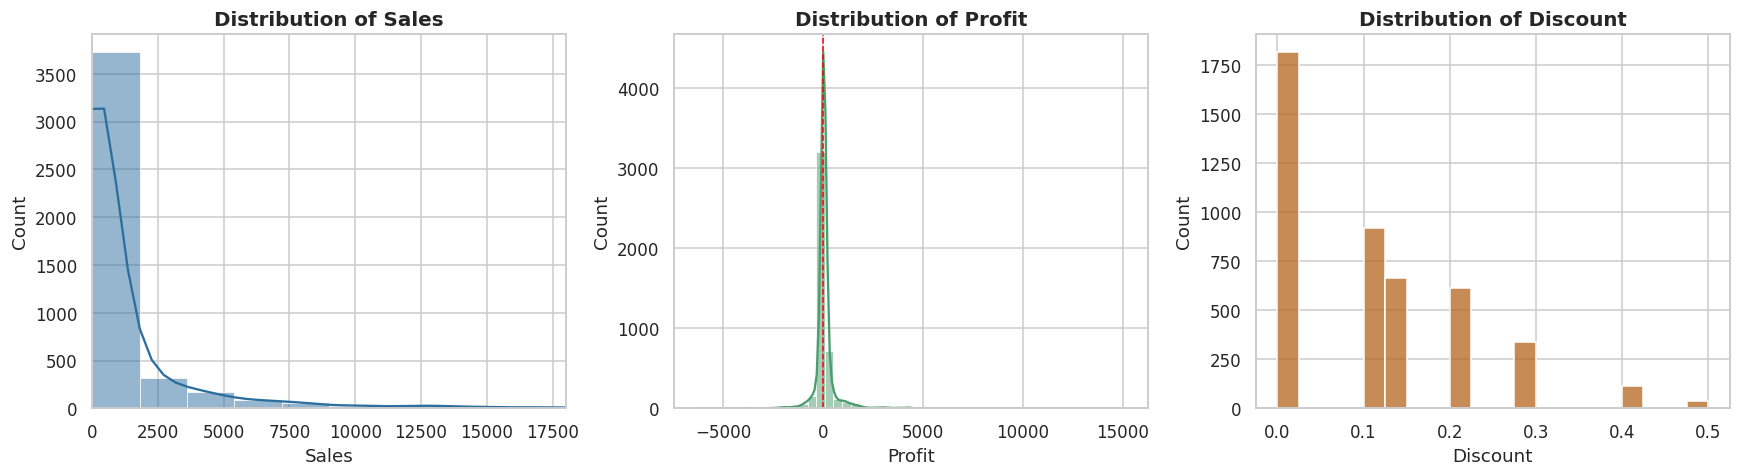

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(df["Sales"], bins=50, kde=True, ax=axes[0], color="#2C6E9E")
axes[0].set_title("Distribution of Sales")
axes[0].set_xlim(0, df["Sales"].quantile(0.99))

sns.histplot(df["Profit"], bins=50, kde=True, ax=axes[1], color="#4C9C6E")
axes[1].set_title("Distribution of Profit")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1)

sns.histplot(df["Discount"], bins=20, ax=axes[2], color="#B5651D")
axes[2].set_title("Distribution of Discount")
plt.tight_layout()
plt.show()

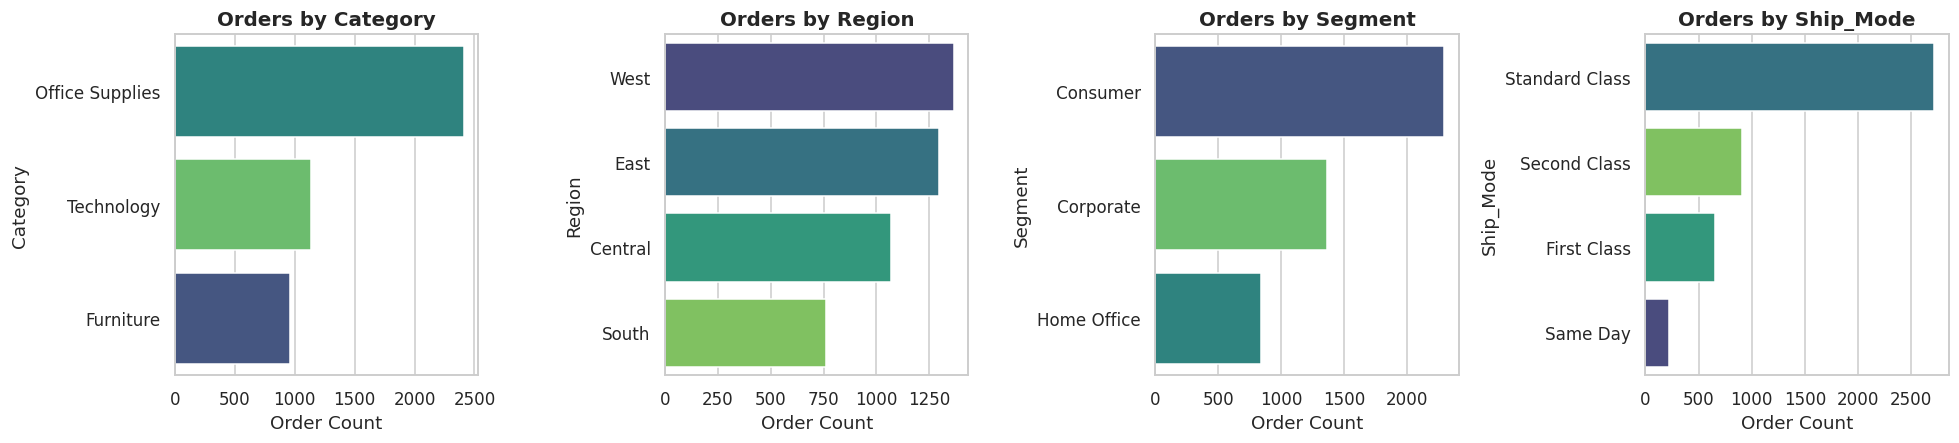

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, col in zip(axes, ["Category", "Region", "Segment", "Ship_Mode"]):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, hue=col, legend=False, ax=ax, palette="viridis")
    ax.set_title(f"Orders by {col}")
    ax.set_xlabel("Order Count")
plt.tight_layout()
plt.show()

<a id="6"></a>
## 6. Outlier Detection

We use box plots for a visual check and the **IQR (Interquartile Range) method** for a
quantitative outlier count: any value below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR` is
flagged as an outlier.

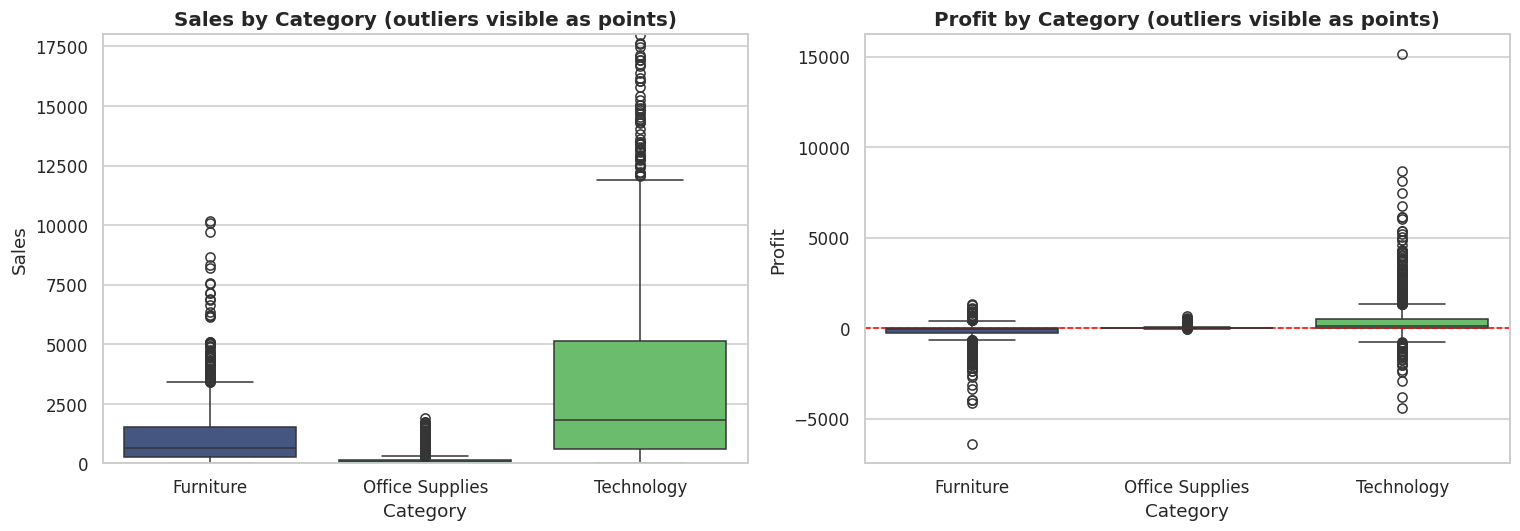

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="Category", y="Sales", hue="Category", legend=False, ax=axes[0], palette="viridis")
axes[0].set_title("Sales by Category (outliers visible as points)")
axes[0].set_ylim(0, df["Sales"].quantile(0.99))

sns.boxplot(data=df, x="Category", y="Profit", hue="Category", legend=False, ax=axes[1], palette="viridis")
axes[1].set_title("Profit by Category (outliers visible as points)")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
plt.tight_layout()
plt.show()

In [13]:
def iqr_outliers(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    return mask, lower, upper

outlier_summary = []
for col in ["Sales", "Profit", "Quantity", "Discount"]:
    mask, lower, upper = iqr_outliers(df[col])
    outlier_summary.append({
        "column": col, "lower_bound": round(lower, 2), "upper_bound": round(upper, 2),
        "n_outliers": int(mask.sum()), "pct_outliers": round(mask.mean() * 100, 2)
    })
outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,column,lower_bound,upper_bound,n_outliers,pct_outliers
0,Sales,-1405.89,2449.75,621,13.80
1,Profit,-88.03,148.80,1267,28.16
2,Quantity,-3.50,8.50,10,0.22
3,Discount,-0.22,0.38,154,3.42


In [14]:
sales_mask, _, sales_upper = iqr_outliers(df["Sales"])
print(f"{sales_mask.sum()} orders ({sales_mask.mean()*100:.1f}%) exceed the Sales upper bound of ${sales_upper:,.0f}")
print("\nTop 10 highest-value orders (potential bulk / large-account deals):")
top_orders = df.loc[sales_mask].sort_values("Sales", ascending=False).head(10)
top_orders[["Order_ID", "Order_Date", "Category", "Sub_Category", "Quantity", "Sales", "Discount", "Profit"]]

621 orders (13.8%) exceed the Sales upper bound of $2,450

Top 10 highest-value orders (potential bulk / large-account deals):


,Order_ID,Order_Date,Category,Sub_Category,Quantity,Sales,Discount,Profit
1011,ORD-2022082,2024-08-18,Technology,Machines,37,90102.17,0.2,-3820.19
344,ORD-2026343,2022-11-12,Technology,Copiers,26,61895.58,0.0,15155.04
1612,ORD-2022623,2023-07-27,Technology,Machines,25,60805.82,0.2,-2409.60
2873,ORD-2026427,2022-08-05,Technology,Copiers,28,58089.71,0.2,-2044.93
556,ORD-2025037,2022-01-11,Technology,Machines,30,56075.33,0.2,1139.94
3937,ORD-2024094,2024-11-11,Technology,Machines,32,51365.16,0.1,6032.68
3655,ORD-2022307,2023-12-19,Technology,Machines,27,47230.55,0.2,-1107.31
3656,ORD-2024120,2022-12-03,Technology,Copiers,21,39344.16,0.1,5179.69
1139,ORD-2024677,2024-08-23,Technology,Machines,23,39223.72,0.2,56.22
3022,ORD-2022142,2024-12-02,Technology,Copiers,30,35319.85,0.0,8684.98


In [15]:
loss_orders = df[df["Profit"] < 0]
print(f"Loss-making orders: {len(loss_orders):,} ({len(loss_orders)/len(df)*100:.1f}% of all orders)")
print(f"Total value destroyed by loss-making orders: ${loss_orders['Profit'].sum():,.2f}")
loss_orders.groupby("Category")["Profit"].agg(["count", "sum"]).sort_values("sum")

Loss-making orders: 1,022 (22.7% of all orders)
Total value destroyed by loss-making orders: $-321,721.10


,count,sum
Category,,
Furniture,684,-233397.47
Technology,264,-87934.42
Office Supplies,74,-389.21


**Interpretation:** A small cluster of very large `Sales` values (~14% by the IQR rule)
mostly represents legitimate bulk Technology purchases (Machines/Copiers) rather than
data errors — they are kept in the dataset but worth flagging to the business as
large-account activity. More concerning is that roughly a fifth of *all* orders are
sold at a loss, concentrated heavily in **Furniture** — this is explored further below.

<a id="7"></a>
## 7. Trends Over Time

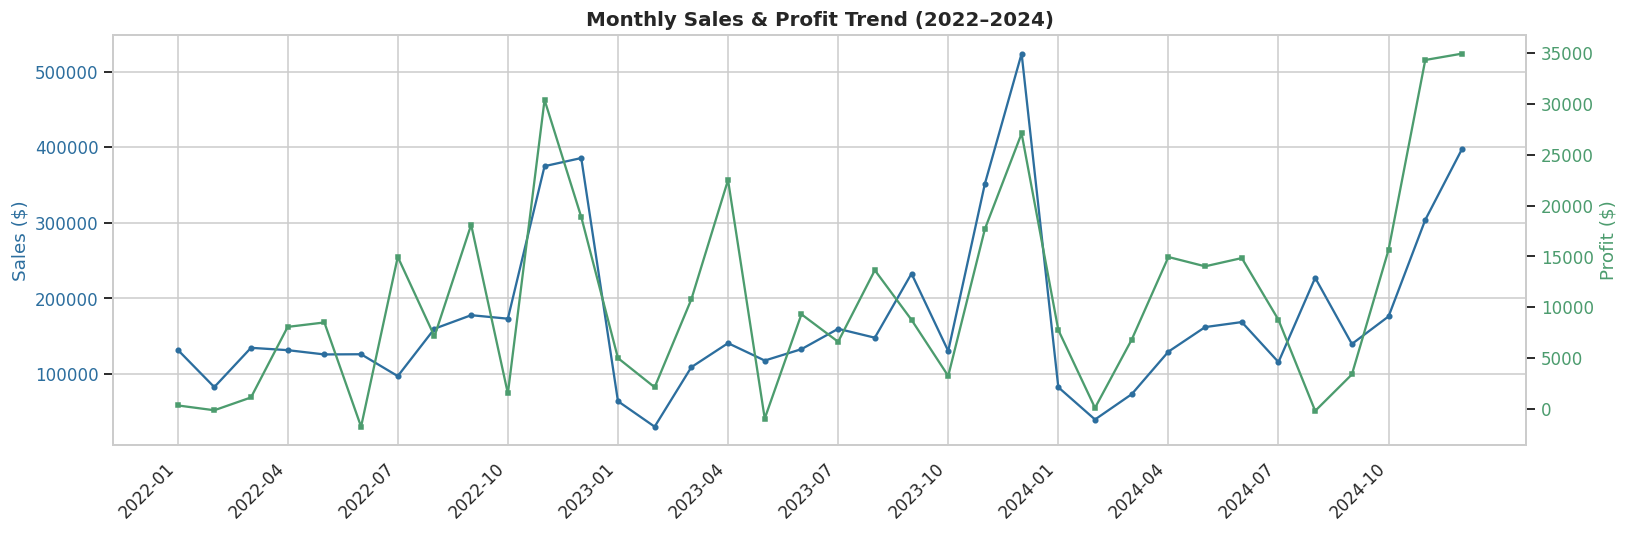

In [16]:
monthly = df.groupby("Order_YearMonth").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum")).reset_index()

fig, ax1 = plt.subplots(figsize=(15, 5))
ax1.plot(monthly["Order_YearMonth"], monthly["Sales"], color="#2C6E9E", marker="o", markersize=3, label="Sales")
ax1.set_ylabel("Sales ($)", color="#2C6E9E")
ax1.tick_params(axis="y", labelcolor="#2C6E9E")
ax1.set_xticks(monthly["Order_YearMonth"][::3])
ax1.set_xticklabels(monthly["Order_YearMonth"][::3], rotation=45, ha="right")

ax2 = ax1.twinx()
ax2.plot(monthly["Order_YearMonth"], monthly["Profit"], color="#4C9C6E", marker="s", markersize=3, label="Profit")
ax2.set_ylabel("Profit ($)", color="#4C9C6E")
ax2.tick_params(axis="y", labelcolor="#4C9C6E")
ax2.grid(False)

plt.title("Monthly Sales & Profit Trend (2022–2024)")
fig.tight_layout()
plt.show()

In [17]:
holiday_share = df[df["Order_Month"].isin([11, 12])]["Sales"].sum() / df["Sales"].sum()
best_month = monthly.loc[monthly["Sales"].idxmax()]
print(f"Highest single month: {best_month['Order_YearMonth']} with ${best_month['Sales']:,.0f} in sales")
print(f"November + December account for {holiday_share*100:.1f}% of total annual sales -> clear holiday-season seasonality")

yearly = df.groupby("Order_Year").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
yearly["YoY_Sales_Growth_%"] = yearly["Sales"].pct_change().mul(100).round(1)
yearly

Highest single month: 2023-12 with $523,963 in sales
November + December account for 37.3% of total annual sales -> clear holiday-season seasonality


,Sales,Profit,YoY_Sales_Growth_%
Order_Year,,,
2022,2102216.99,107101.08,NaN
2023,2141964.79,125787.52,1.9
2024,2016507.07,155322.51,-5.9


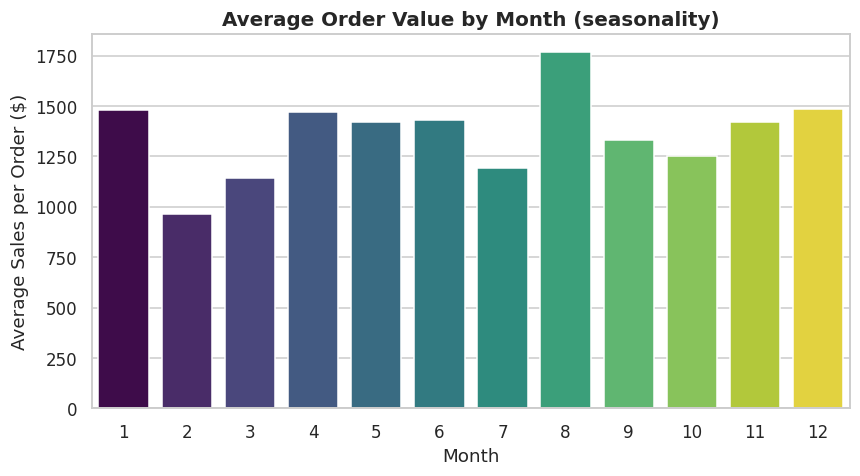

In [18]:
fig, ax = plt.subplots(figsize=(8, 4.5))
month_avg = df.groupby("Order_Month")["Sales"].mean()
sns.barplot(x=month_avg.index, y=month_avg.values, hue=month_avg.index, legend=False, palette="viridis", ax=ax)
ax.set_title("Average Order Value by Month (seasonality)")
ax.set_xlabel("Month")
ax.set_ylabel("Average Sales per Order ($)")
plt.tight_layout()
plt.show()

<a id="8"></a>
## 8. Relationships Between Variables

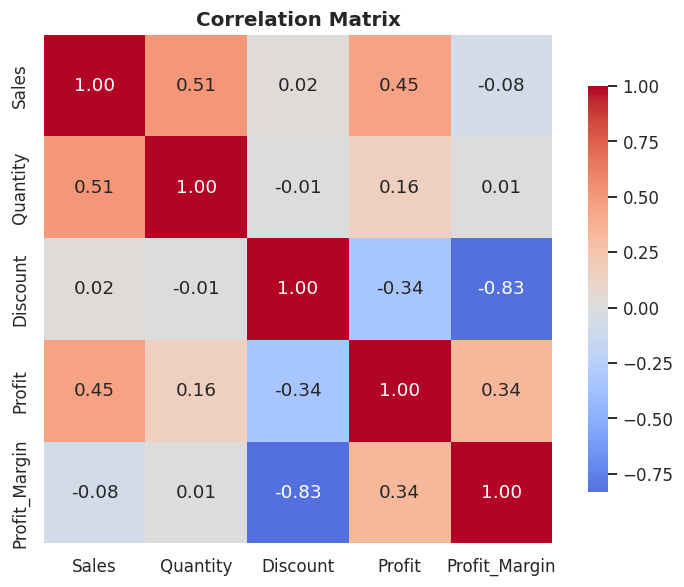

In [19]:
num_cols = ["Sales", "Quantity", "Discount", "Profit", "Profit_Margin"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

Correlation of Discount with Profit Margin: -0.833


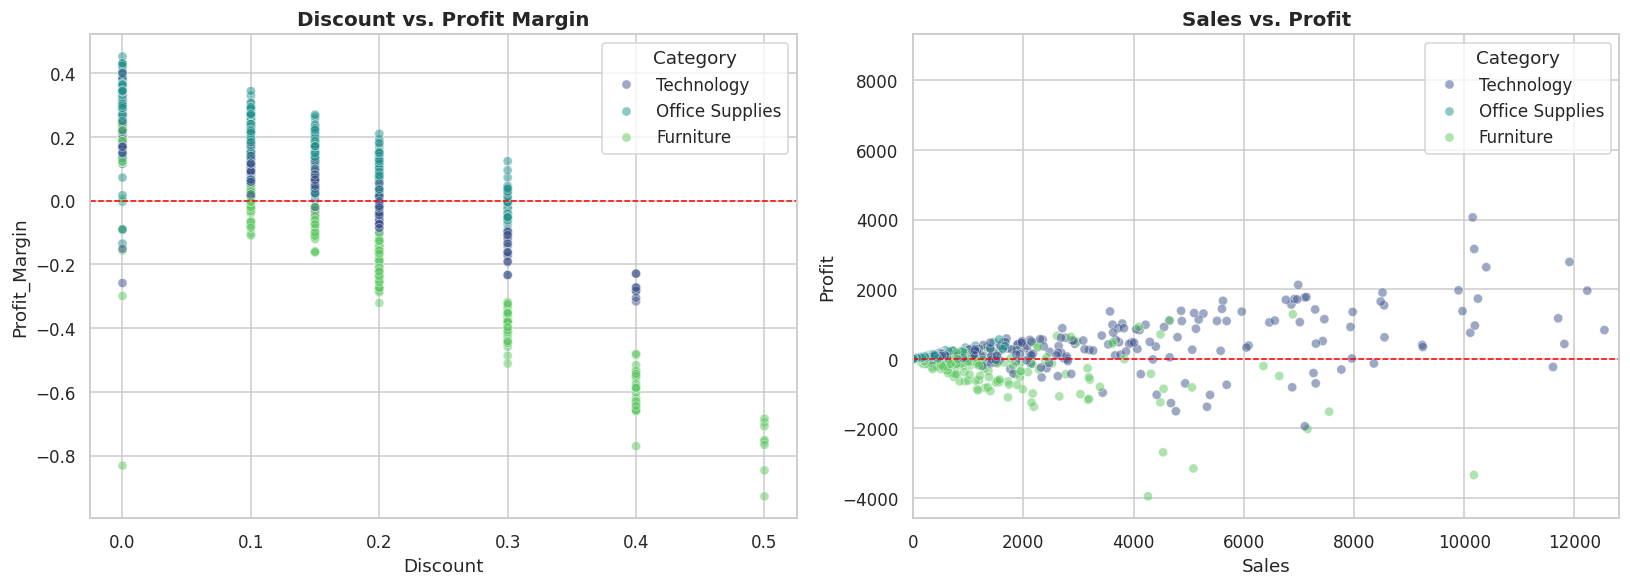

In [20]:
print("Correlation of Discount with Profit Margin:", round(df["Discount"].corr(df["Profit_Margin"]), 3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.scatterplot(data=df.sample(1200, random_state=1), x="Discount", y="Profit_Margin",
                 hue="Category", alpha=0.5, ax=axes[0], palette="viridis")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Discount vs. Profit Margin")

sns.scatterplot(data=df.sample(1200, random_state=1), x="Sales", y="Profit",
                 hue="Category", alpha=0.5, ax=axes[1], palette="viridis")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_xlim(0, df["Sales"].quantile(0.98))
axes[1].set_title("Sales vs. Profit")
plt.tight_layout()
plt.show()

**Interpretation:** Discount and profit margin are **strongly negatively correlated**
(~-0.83). As discounts climb past roughly 20–30%, profit margin routinely turns
negative — discounting is the single strongest driver of unprofitable orders in this
dataset, far more than order size or category alone.

<a id="9"></a>
## 9. Category / Region / Segment Performance

,Sales,Profit,Orders,Profit_Margin_%
Category,,,,
Technology,4832124.71,505592.02,1132,10.5
Furniture,1120177.09,-187679.85,957,-16.8
Office Supplies,308387.05,70298.94,2411,22.8


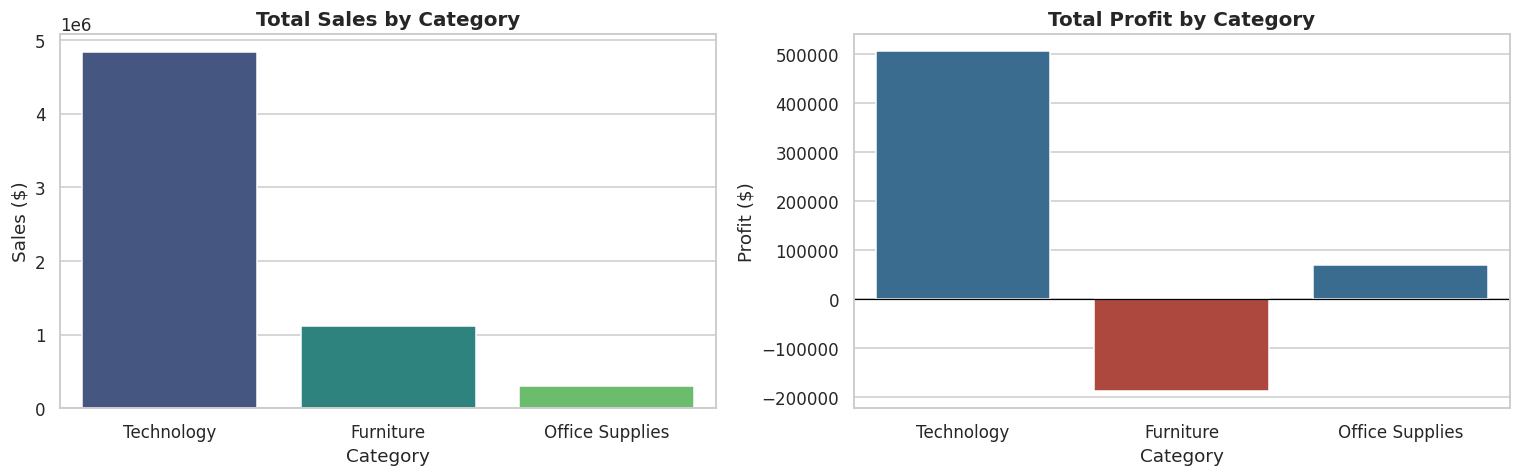

In [21]:
cat_perf = df.groupby("Category").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"),
                                        Orders=("Order_ID", "count"))
cat_perf["Profit_Margin_%"] = (cat_perf["Profit"] / cat_perf["Sales"] * 100).round(1)
cat_perf = cat_perf.sort_values("Sales", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(x=cat_perf.index, y=cat_perf["Sales"], hue=cat_perf.index, legend=False, ax=axes[0], palette="viridis")
axes[0].set_title("Total Sales by Category")
axes[0].set_ylabel("Sales ($)")

colors = ["#c0392b" if v < 0 else "#2C6E9E" for v in cat_perf["Profit"]]
sns.barplot(x=cat_perf.index, y=cat_perf["Profit"], hue=cat_perf.index, legend=False, ax=axes[1], palette=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Total Profit by Category")
axes[1].set_ylabel("Profit ($)")
plt.tight_layout()
plt.show()
cat_perf

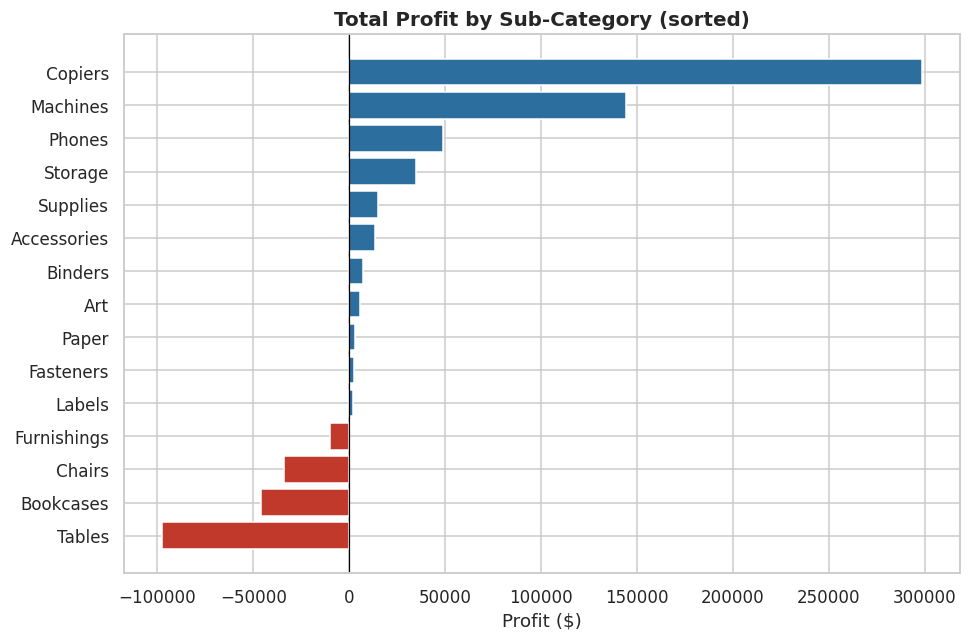

In [22]:
subcat_perf = df.groupby("Sub_Category").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum")).sort_values("Profit")
fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#c0392b" if v < 0 else "#2C6E9E" for v in subcat_perf["Profit"]]
ax.barh(subcat_perf.index, subcat_perf["Profit"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Total Profit by Sub-Category (sorted)")
ax.set_xlabel("Profit ($)")
plt.tight_layout()
plt.show()

Region performance:
              Sales     Profit  Profit_Margin_%
Region                                         
West     1825302.27  147170.07              8.1
Central  1463021.12   91246.79              6.2
East     1951552.07  101096.41              5.2
South    1020813.39   48697.84              4.8

Segment performance:
                  Sales     Profit  Profit_Margin_%
Segment                                            
Corporate    2059407.37  136755.79              6.6
Consumer     3093357.59  192424.72              6.2
Home Office  1107923.89   59030.60              5.3


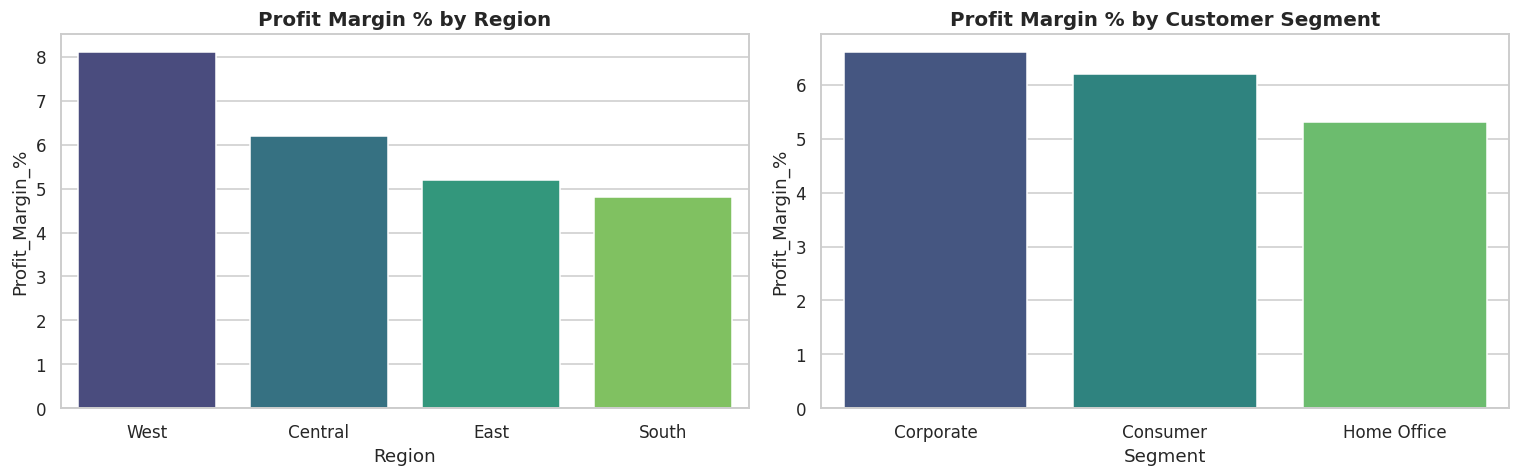

In [23]:
region_perf = df.groupby("Region").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
region_perf["Profit_Margin_%"] = (region_perf["Profit"] / region_perf["Sales"] * 100).round(1)
region_perf = region_perf.sort_values("Profit_Margin_%", ascending=False)

segment_perf = df.groupby("Segment").agg(Sales=("Sales", "sum"), Profit=("Profit", "sum"))
segment_perf["Profit_Margin_%"] = (segment_perf["Profit"] / segment_perf["Sales"] * 100).round(1)
segment_perf = segment_perf.sort_values("Profit_Margin_%", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(x=region_perf.index, y=region_perf["Profit_Margin_%"], hue=region_perf.index, legend=False, ax=axes[0], palette="viridis")
axes[0].set_title("Profit Margin % by Region")
sns.barplot(x=segment_perf.index, y=segment_perf["Profit_Margin_%"], hue=segment_perf.index, legend=False, ax=axes[1], palette="viridis")
axes[1].set_title("Profit Margin % by Customer Segment")
plt.tight_layout()
plt.show()
print("Region performance:")
print(region_perf)
print("\nSegment performance:")
print(segment_perf)

In [24]:
top_customers = df.groupby("Customer_Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_customers.to_frame("Total_Sales")

,Total_Sales
Customer_Name,
Robert Miller,112465.30
Kevin Thomas,110846.25
Robert Moore,92122.66
David Miller,79723.93
John Hernandez,69310.04
Robert Martinez,68444.80
Nancy Brown,66672.99
Barbara Rodriguez,66456.12
Sandra Moore,64990.36


<a id="10"></a>
## 10. Answering Key Business Questions

Using the summary statistics computed above, we can now directly answer the
business questions this analysis was built to address.

In [25]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
overall_margin = total_profit / total_sales
best_cat = cat_perf["Profit"].idxmax()
worst_cat = cat_perf["Profit"].idxmin()
worst_subcat = subcat_perf["Profit"].idxmin()
best_region = region_perf["Profit_Margin_%"].idxmax()
worst_region = region_perf["Profit_Margin_%"].idxmin()
best_segment = segment_perf["Profit_Margin_%"].idxmax()

def money(x):
    return f"-${abs(x):,.0f}" if x < 0 else f"${x:,.0f}"

print("BUSINESS Q&A SUMMARY")
print("=" * 60)
print(f"Q1. What is our overall sales & profitability?")
print(f"    -> Total Sales: {money(total_sales)} | Total Profit: {money(total_profit)} | Overall Margin: {overall_margin*100:.1f}%\n")

print(f"Q2. Which category makes the most money, and which loses money?")
print(f"    -> Best: {best_cat} ({money(cat_perf.loc[best_cat,'Profit'])} profit)")
print(f"    -> Worst: {worst_cat} ({money(cat_perf.loc[worst_cat,'Profit'])} profit) -- currently UNPROFITABLE overall\n")

print(f"Q3. Which specific product line is the biggest problem?")
print(f"    -> {worst_subcat}: {money(subcat_perf.loc[worst_subcat,'Profit'])} in losses\n")

print(f"Q4. Which region and customer segment are most/least profitable?")
print(f"    -> Best region: {best_region} ({region_perf.loc[best_region,'Profit_Margin_%']}% margin)")
print(f"    -> Weakest region: {worst_region} ({region_perf.loc[worst_region,'Profit_Margin_%']}% margin)")
print(f"    -> Most profitable segment: {best_segment} ({segment_perf.loc[best_segment,'Profit_Margin_%']}% margin)\n")

print(f"Q5. Does discounting hurt profitability?")
print(f"    -> Yes -- Discount vs Profit Margin correlation = {df['Discount'].corr(df['Profit_Margin']):.2f} (strong negative)")
print(f"    -> {(df['Profit']<0).mean()*100:.1f}% of all orders are sold at a loss\n")

print(f"Q6. Is there seasonality we should plan around?")
print(f"    -> Nov + Dec generate {holiday_share*100:.1f}% of annual sales -- clear holiday-season demand spike")

BUSINESS Q&A SUMMARY
Q1. What is our overall sales & profitability?
    -> Total Sales: $6,260,689 | Total Profit: $388,211 | Overall Margin: 6.2%

Q2. Which category makes the most money, and which loses money?
    -> Best: Technology ($505,592 profit)
    -> Worst: Furniture (-$187,680 profit) -- currently UNPROFITABLE overall

Q3. Which specific product line is the biggest problem?
    -> Tables: -$97,765 in losses

Q4. Which region and customer segment are most/least profitable?
    -> Best region: West (8.1% margin)
    -> Weakest region: South (4.8% margin)
    -> Most profitable segment: Corporate (6.6% margin)

Q5. Does discounting hurt profitability?
    -> Yes -- Discount vs Profit Margin correlation = -0.83 (strong negative)
    -> 22.7% of all orders are sold at a loss

Q6. Is there seasonality we should plan around?
    -> Nov + Dec generate 37.3% of annual sales -- clear holiday-season demand spike


<a id="11"></a>
## 11. Key Findings & Recommendations

**Findings**
1. **Furniture is the problem category.** It generates meaningful revenue but is
   *unprofitable overall*, driven almost entirely by the **Tables** sub-category,
   which loses money on net.
2. **Discounting is the primary driver of losses**, not order size. Discount and
   profit margin correlate strongly negatively (≈ -0.83); once discounts exceed
   roughly 20–30%, orders routinely become unprofitable across every category.
3. **About one in five orders (≈23%) is sold at a loss**, concentrated in
   over-discounted Furniture orders.
4. **Technology is the clear sales and profit engine** (largest revenue share and
   solid margin), and **Office Supplies has the best margin percentage**, even
   though its total revenue is small.
5. **Strong holiday seasonality** — November and December alone drive over a third
   of annual sales, which should inform inventory and staffing plans.
6. **Regional/segment performance varies**: the West region and the Corporate
   segment post the healthiest margins, while the South region and Home Office
   segment lag behind.
7. A small set of high-value bulk Technology orders (~14% of orders by the IQR
   rule) inflate the upper tail of the Sales distribution — these are legitimate
   large-account deals, not data errors, but worth tracking separately from
   typical order sizes.

**Recommendations**
- Cap or restructure discounts on **Furniture**, and specifically review pricing
  and discount policy for **Tables**.
- Set an internal **discount ceiling (~20%)** past which approval is required,
  given how sharply margin erodes beyond that point.
- Invest further in **Technology and Office Supplies**, which combine strong
  revenue and healthy margins.
- Plan **inventory and staffing for the Nov–Dec peak** given the pronounced
  seasonal spike.
- Investigate why the **South region / Home Office segment** underperform on
  margin — e.g., heavier reliance on discounting or shipping cost mix.